plot 2

- Separate plot: Subset 30 neurons and add regression line for each of them (number of points per neuron in the regression = number of images). If messy, decrease to 10 neurons

plot 3

- Separate plot: all neurons: histogram = distribution of regression slopes (number of points = number of neurons)

plot 4

- Now combined plot: plot as kernel density all distribution of slopes for each sigmaXnoise condition (6 lines)
- all neurons

#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
#from predict_loop_functions import predict_loop, noise_iterations 
#from predict_loop_functions import remove_x
from scipy.stats import linregress, gaussian_kde

In [2]:
def remove_x(arr: list or np.array, remove: str, k_percent: int):
    """
    Parameters
    ----------
    arr: list or np.array
        object that we are removing from
    remove: str
        where to remove values from
    k_percent: int
        what percent to cut off (enter as int, ie if you want to remove 10% enter 10)
    """
    if len(arr) <= 1:
        return np.arange(len(arr))  
        
    n_remove = int(k_percent / 100 * len(arr))
    n_keep = max(1, len(arr) - n_remove)
    
    if remove == 'top':
        return arr[:n_keep]
    elif remove == 'bottom':  # remove == 'bottom'
        return arr[-n_keep:]
    else: raise ValueError("Please enter 'top' or 'bottom' as an argument for remove.")

In [3]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [3]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
                    1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [ ]:
d3_sum, d3_mean, d3_var, d3_labels = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [ ]:
d15_sum, d15_mean, d15_var, d15_labels = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [ ]:
d30_sum, d30_mean, d30_var, d30_labels = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [ ]:
c3_sum, c3_mean, c3_var, c3_labels = predict_loop('constant', image_stack, 3, [[4,7]])

In [ ]:
c15_sum, c15_mean, c15_var, c15_labels = predict_loop('constant', image_stack, 15, [[4,7]])

In [ ]:
c30_sum, c30_mean, c30_var, c30_labels = predict_loop('constant', image_stack, 30, [[4,7]])

In [ ]:
dbin_sum, dbin_mean, dbin_var, dbin_labels = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
cbin_sum, cbin_mean, cbin_var, cbin_labels = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
# save predictions to predictions_july21
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type_output in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_output
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

##### add no noise prediction for turning curves

In [ ]:
no_noise_sum, no_noise_mean, no_noise_var, no_noise_labels = predict_loop('no noise', image_stack, 0, [[4,7]])

In [ ]:
for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = 'no_noise' + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions

In [3]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_noise + '.npy'
        var_name = noise + type_noise
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [4]:
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = noise + type_noise + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type_noise + '_r' + str(region)
            globals()[array_name] = np.load(path)

##### 30 random neurons for each region

In [11]:
# region 1
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]

In [12]:
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]

In [13]:
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]

In [14]:
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

#### plot 2

In [43]:
d3_mean_r1[:, r1_randoms].shape

(5, 30)

In [ ]:
# means should be [d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1.....]

In [26]:
# plot 30 random neurons and put regression, make sure neurons is list of random neurons for each region
def mean_var_scatter_4x4_regression(means, vars, neurons, main_title: str):
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
    
    for i in range(4):
        neuron_arr = neurons[i]
        for j in range(4):
            idx = i * 4 + j
            ax = axes[i, j] # first iterate j through different sigmas
            
            x = means[idx]
            y = vars[idx]
            x = x[:, neuron_arr].flatten()
            y = y[:, neuron_arr].flatten()
            
            cmap = plt.get_cmap('viridis')

            num_points = len(x)
            group_size = means[idx].shape[0]
            num_groups = int(np.ceil(num_points / group_size))

            # Create an array to assign the same color to every 5 points
            color_indices = np.repeat(np.linspace(0, 1, num_groups), group_size)[:num_points]
            colors = cmap(color_indices)
            
            ax.scatter(x, y, marker='^', color = colors)

            linregress_result = linregress(x, y)
            x_fit = np.linspace(np.min(x), np.max(x), len(x))
            y_fit = linregress_result.intercept + linregress_result.slope * x_fit

            ax.plot(x_fit, y_fit, color='red', label='Regression line', linewidth=2)

            se_fit = linregress_result.stderr * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
            ax.fill_between(x_fit, y_fit - 1.96 * se_fit, y_fit + 1.96 * se_fit, color='gray', alpha=0.3, label='95% CI')
            
            
            rsq = linregress_result.rvalue ** 2

            y = ax.get_ylim()[1]
            ax.text(1, y - (1 if y>1 else .01), f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.slope:.3f}, {linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
                    fontsize=7, verticalalignment='top')
                

            ax.grid(True)

            if i == 0: title_region = 'V1' 
            elif i == 1: title_region = 'LM'
            elif i == 2: title_region = 'AL'
            else: title_region = 'RL'

            if j == 0:
                ax.set_ylabel(f'(Region: {title_region})\n\nVariance in\nPredicted Spike Count')
            if i == 3:
                ax.set_xlabel(f'Mean Prediced Spike Count\n\n({sigmas[j]})')  
    
    plt.tight_layout()
    plt.show()

In [7]:
scatter_means = [d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1,
                 d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2,
                 d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3,
                 d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]


In [8]:
scatter_vars = [d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1,
               d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2,
               d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3,
               d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]


In [15]:
randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

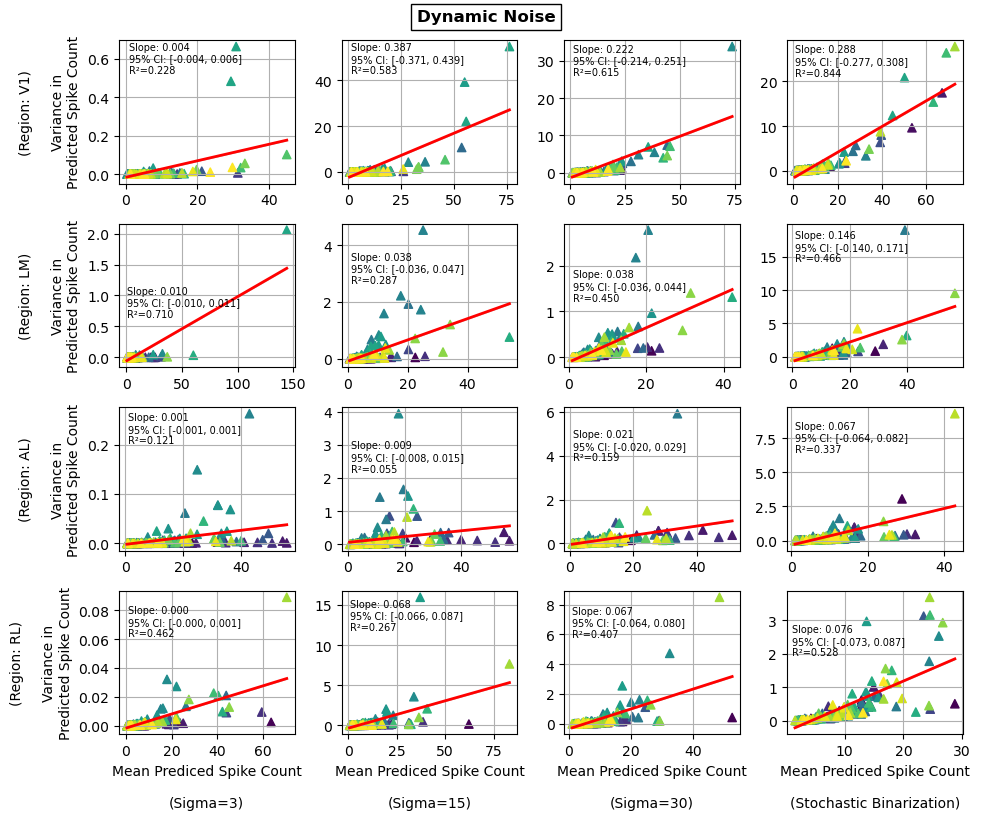

In [ ]:
mean_var_scatter_4x4_regression(scatter_means, scatter_vars, randoms, 'Dynamic Noise')

In [21]:
scatter_means = [c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1,
                 c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2,
                 c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3,
                 c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]


In [22]:
scatter_vars = [c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1,
               c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2,
               c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3,
               c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]


In [23]:
randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

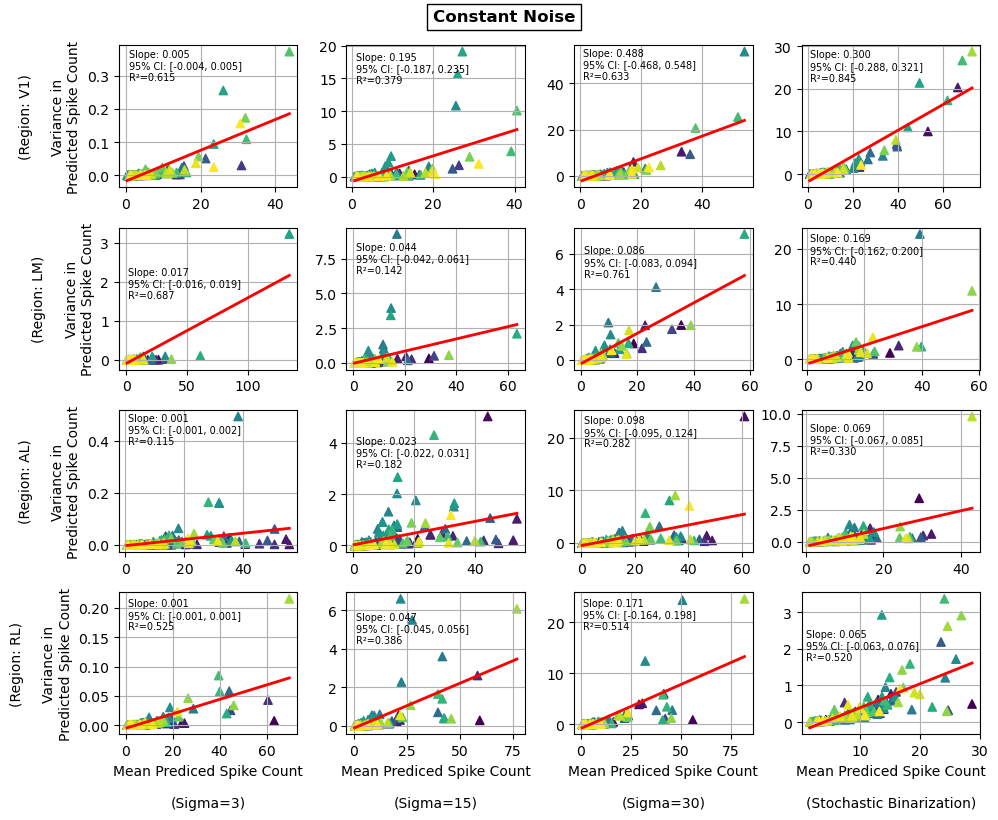

In [ ]:
mean_var_scatter_4x4_regression(scatter_means, scatter_vars, randoms, 'Constant Noise')

#### plot 3

In [6]:
def mean_var_hist_4x4(means, vars, main_title: str):
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
    cmap = plt.get_cmap('viridis')
    row_colors = [cmap(0.2), cmap(0.4), cmap(0.6), cmap(0.8)] 

    for i in range(4):
        for j in range(4):
            idx = i * 4 + j
            ax = axes[i, j] 
            
            x = means[idx]
            y = vars[idx]
            slope_arr = np.empty((x.shape[1]))

            for neuron in range(y.shape[1]):
                regression = linregress(x[:, neuron], y[:, neuron])
                slope_arr[neuron] = regression.slope                   

            ax.hist(slope_arr, bins = 50, color = row_colors[i])

            if i == 0: title_region = 'V1' 
            elif i == 1: title_region = 'LM'
            elif i == 2: title_region = 'AL'
            else: title_region = 'RL'

            if j == 0:
                ax.set_ylabel(f'(Region: {title_region})\n\nCount')
            if i == 3:
                ax.set_xlabel(f'Slope from\nMean Variance Regression\n\n({sigmas[j]})')  
    
    plt.tight_layout()
    plt.show()

In [7]:
scatter_means = [d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1,
                 d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2,
                 d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3,
                 d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]


In [8]:
scatter_vars = [d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1,
               d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2,
               d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3,
               d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]


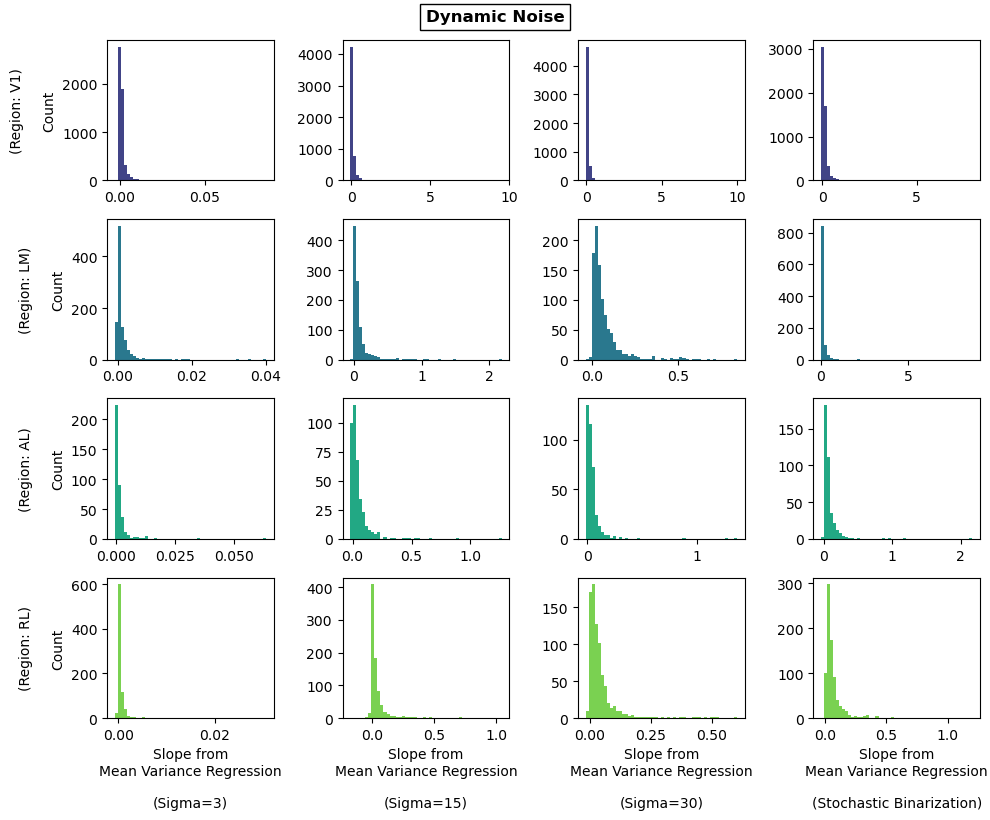

In [9]:
mean_var_hist_4x4(scatter_means, scatter_vars, 'Dynamic Noise')

In [10]:
scatter_means = [c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1,
                 c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2,
                 c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3,
                 c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]


In [11]:
scatter_vars = [c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1,
               c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2,
               c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3,
               c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]


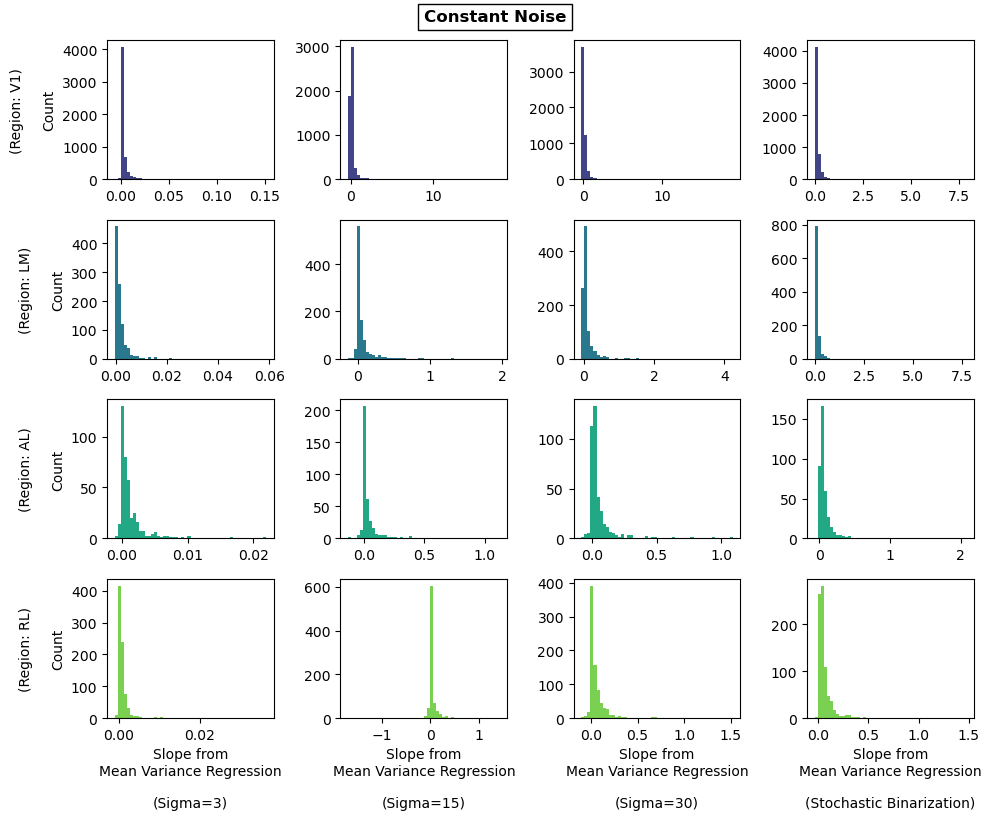

In [12]:
mean_var_hist_4x4(scatter_means, scatter_vars, 'Constant Noise')

#### plot 4

In [5]:
kde_means = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1, c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2, c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3, c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4, c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]


In [6]:
kde_vars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1, c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2, c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3, c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4, c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]

In [19]:
# input should just be mean and var arrays or 2d lists
def kde_2x2(list_means, list_vars, title):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.0, title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    cmap = plt.get_cmap('viridis')
    row_colors = [cmap(0.2), cmap(0.4), cmap(0.6), cmap(0.8)] 
    for i in range(2):
        for j in range(2):
            idx = i * 2 + j
            ax = axes[i, j]

            means = list_means[idx]
            vars = list_vars[idx]

            # first get arrays of slopes from list
            kde_slopes = np.empty((sum(x.shape[1] for x in means)))

            reg_counter = 0
            for x, y in zip(means, vars):
                x = x.flatten()
                y = y.flatten()
                print(f'run {idx}, var of y = {np.var(y)}')
                regression = linregress(x, y)
                kde_slopes[reg_counter] = regression.slope
                reg_counter +=1

            print(f'for nulls: {np.any(np.isnan(kde_slopes))}\nfor infs: {np.any(np.isinf(kde_slopes))}')
            kde = gaussian_kde(kde_slopes)
            x_range = np.linspace(np.min(kde_slopes), np.max(kde_slopes), 750) # how many samples to generate?
            kde_values = kde(x_range)

            ax.plot(x_range, kde_values, color = row_colors[idx])
            ax.fill_between(x_range, kde_values, alpha = 0.5)

            if i == 1: ax.set_xlabel('Slope from\nprior regression')
            if j == 0: ax.set_ylabel('Density')

            if idx == 0: region_title = 'V1'
            elif idx == 1: region_title = 'LM'
            elif idx == 2: region_title = 'AL'
            else: region_title = 'RL'
            ax.set_title(f'Region: {region_title}')

    plt.tight_layout()
    plt.show()

run 0, var of y = 0.07623274649828485
run 0, var of y = 3902.7105526116125
run 0, var of y = 5826.4916261405715
run 0, var of y = 1629.4629332799336
run 0, var of y = 0.2626520773434943
run 0, var of y = 13395.3491342126
run 0, var of y = 9706.428724480871
run 0, var of y = 1850.0898648748157
for nulls: False
for infs: False
run 1, var of y = 0.03489340059365562
run 1, var of y = 31.13665868917507
run 1, var of y = 16.74758010667832
run 1, var of y = 6222.351370803318
run 1, var of y = 0.07690028861743498
run 1, var of y = 35.26799602634835
run 1, var of y = 171.17288307274697
run 1, var of y = 4909.444232731831
for nulls: False
for infs: False
run 2, var of y = 0.0019608008985847456
run 2, var of y = 18.55916253775208
run 2, var of y = 37.26912062285431
run 2, var of y = 25.516817742473147
run 2, var of y = 0.0013686130440646708
run 2, var of y = 3.6367429130883404
run 2, var of y = 3.9512594637980882
run 2, var of y = 22.33643212961825
for nulls: False
for infs: False
run 3, var of y

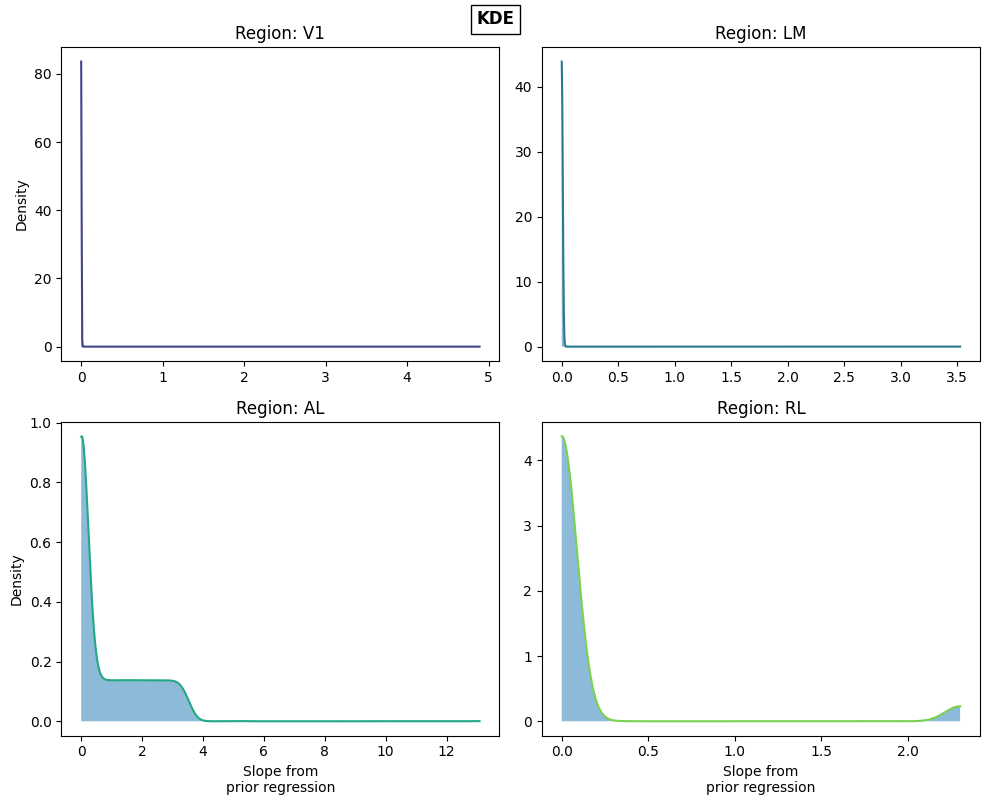

In [30]:
kde_2x2(kde_means, kde_vars, 'KDE')